#ML4Net - Lab 3

## Team members

Aina Tolsanas (284017) | Martina Frisach (NIA 2) | Anna Vilacís (286004)

## Description

In this lab, you will train a time series forecaster using Federated Learning (FL).

The dataset you are going to use contains data from multiple APs. In particular, each AP's dataset contains the following features:

* `datetime` is the timestamp (date) at which the measurement was taken
* `Bytes` is the number of Bytes contributed at the corresponding datetime
* `Active Connections` is the number of active connections (users connected to the AP) at the corresponding datetime
* `Active Users` is the number of active users at the corresponding datetime
* `AP ID` is the ID of the AP where the measurement was taken

Original dataset: Chen, W., Lyu, F., Wu, F., Yang, P., & Ren, J. (2021). Flag: Flexible, accurate, and long-time user load prediction in large-scale WiFi system using deep RNN. IEEE Internet of Things Journal, 8(22), 16510-16521.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   **Submission deadline: 8 June 2026 (EoB).**

In [1]:
#IMPORTS:

import pickle
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import numpy as np
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, clone_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Setting up the environment

1. Connect your Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [3]:
# !wget https://github.com/fwilhelmi/fwilhelmi.github.io/blob/master/files/datasetLab3.pkl
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/master/files/datasetLab3.pkl

--2026-05-30 21:50:07--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/master/files/datasetLab3.pkl
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl [following]
--2026-05-30 21:50:08--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7178423 (6.8M) [application/octet-stream]
Saving to: ‘datasetLab3.pkl’

datasetLab3.pkl     100%[===================>]   6.85M  --.-KB/s    in 0.08s   

2026-05-30 21:50:08 (86.7 MB/s) - ‘datasetLab3.pkl’ saved

3. Define the main path of the code

In [4]:
mypath="/content/drive/Shareddrives/ML4N/LAB3"

4. Extract the source code to the destination folder

In [5]:
mkdir $mypath; cp datasetLab3.pkl $mypath; cd $mypath;

mkdir: cannot create directory ‘/content/drive/Shareddrives/ML4N/LAB3’: File exists


## Loading the data




Load the data from the pickle file (https://docs.python.org/3/library/pickle.html) that contains the dataset.

**Important:** If you have issues with the dataset after automatically downloading and extracting it, download it and move it manually to the indicated folder.

In [6]:
# import pickle
# import os

# print(os.getcwd())
# print(os.path.exists('datasetLab3.pkl'))

# # Open and load the pickle file
# try:
#     with open('datasetLab3.pkl', 'rb') as f:
#         loaded_data = pickle.load(f)
#     print("Data loaded successfully:")
#     print(loaded_data)
# except FileNotFoundError:
#     print("Error: 'datasetLab3.pkl' not found.")
# except Exception as e:
#     print(f"An error occurred: {e}")

# We have downloaded manually and moved it manually to the folder too.

with open('/content/drive/Shareddrives/ML4N/LAB3/datasetLab3.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

print("Data loaded successfully:")
print(loaded_data)

Data loaded successfully:
                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
...                    ...                 ...           ...     ...
2019-05-14 07:10:00    0.0            0.000000           0.0   7-104
2019-05-14 07:20:00    0.0            0.000000           0.0   7-104
2019-05-14 07:30:00    0.0            0.000000           0.0   7-104
2019-05-14 07:40:00    0.0            0.000000           0.0   7-104
2019-05-14 07:50:00    0.0            0.034091           0.0   7-104

[211064 rows x 4 columns]


## EXERCISES

### Exercise 1:

Analyze the data from the different APs and discuss their properites (stationarity, trends, seasonality).

Select 2 or 3 key APs showing different properties and generate:

* Line plots (to plot the load vs the time)
* Autocorrelation plots (to show the relationship between past and future samples of the load)
* An Augmented Dickey-Fuller test (to study the stationarity of the AP)



In [7]:
# We choose just 3 APs from all the ones. To do so first we vizualize all the APs.
print("APs disponibles:", loaded_data['AP ID'].unique())

APs disponibles: ['7-1012' '7-1013' '7-1021' '7-1043' '7-1019' '7-1071' '7-1113' '7-1048'
 '7-1101' '7-1026' '7-1129' '7-112' '7-100' '7-111' '7-1030' '7-1117'
 '7-1126' '7-1099' '7-1052' '7-1087' '7-108' '7-1022' '7-1018' '7-1059'
 '7-1054' '7-110' '7-1058' '7-1094' '7-1064' '7-102' '7-1044' '7-1002'
 '7-1096' '7-1014' '7-1082' '7-1088' '7-1106' '7-1063' '7-1114' '7-1137'
 '7-1004' '7-1045' '7-1125' '7-1036' '7-1124' '7-1034' '7-1083' '7-1072'
 '7-1033' '7-1069' '7-1127' '7-1005' '7-1130' '7-1047' '7-1020' '7-1066'
 '7-1039' '7-1134' '7-1003' '7-1120' '7-1131' '7-1009' '7-1084' '7-1074'
 '7-1062' '7-1025' '7-1089' '7-1098' '7-1006' '7-1139' '7-10' '7-1133'
 '7-1060' '7-1032' '7-106' '7-1057' '7-101' '7-1102' '7-1085' '7-1053'
 '7-107' '7-1121' '7-1023' '7-1097' '7-1050' '7-1037' '7-11' '7-1136'
 '7-1040' '7-1015' '7-1079' '7-1065' '7-1104' '7-105' '7-103' '7-1100'
 '7-1056' '7-1051' '7-114' '7-104']


In [8]:
# We choose 3 randomly
ap1_id = '7-1012'
ap2_id = '7-100'
ap3_id = '7-1089'

ap1 = loaded_data[loaded_data['AP ID'] == ap1_id]['Active Users']
ap2 = loaded_data[loaded_data['AP ID'] == ap2_id]['Active Users']
ap3 = loaded_data[loaded_data['AP ID'] == ap3_id]['Active Users']

print(f"AP1 ({ap1_id}): {len(ap1)} mostres")
print(f"AP2 ({ap2_id}): {len(ap2)} mostres")
print(f"AP3 ({ap3_id}): {len(ap3)} mostres")

AP1 (7-1012): 2071 mostres
AP2 (7-100): 2068 mostres
AP3 (7-1089): 2053 mostres


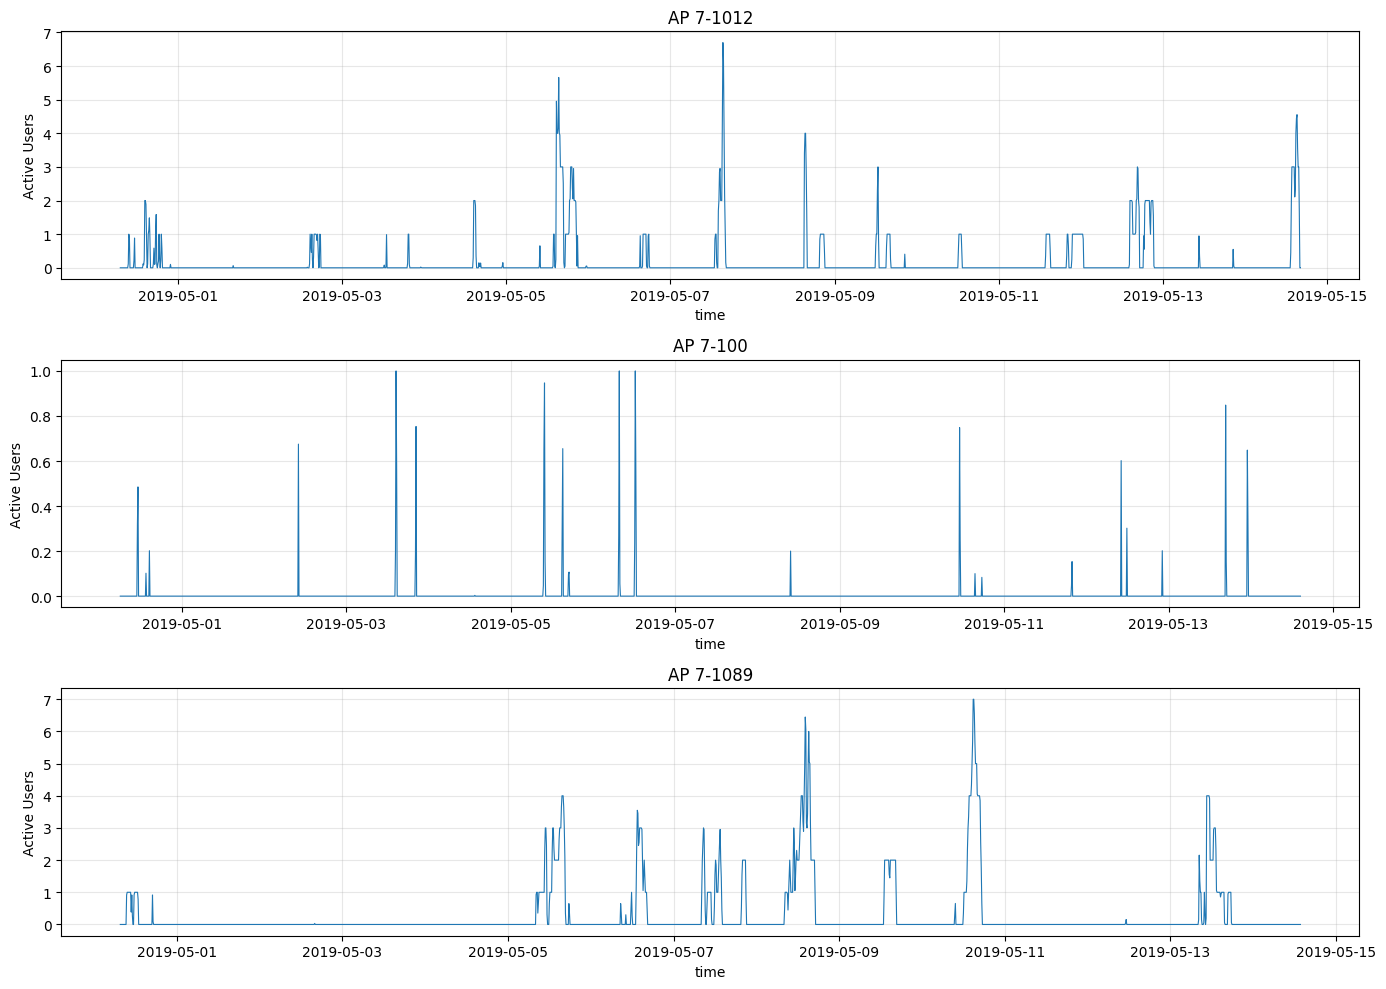

In [9]:
# Line plots és la càrrega (Bytes o Active Users) al llarg del temps per a cada AP.
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, ap, ap_id in zip(axes, [ap1, ap2, ap3], [ap1_id, ap2_id, ap3_id]):
    ax.plot(ap.index, ap.values, linewidth=0.8)
    ax.set_title(f'AP {ap_id}')
    ax.set_xlabel('time')
    ax.set_ylabel('Active Users')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

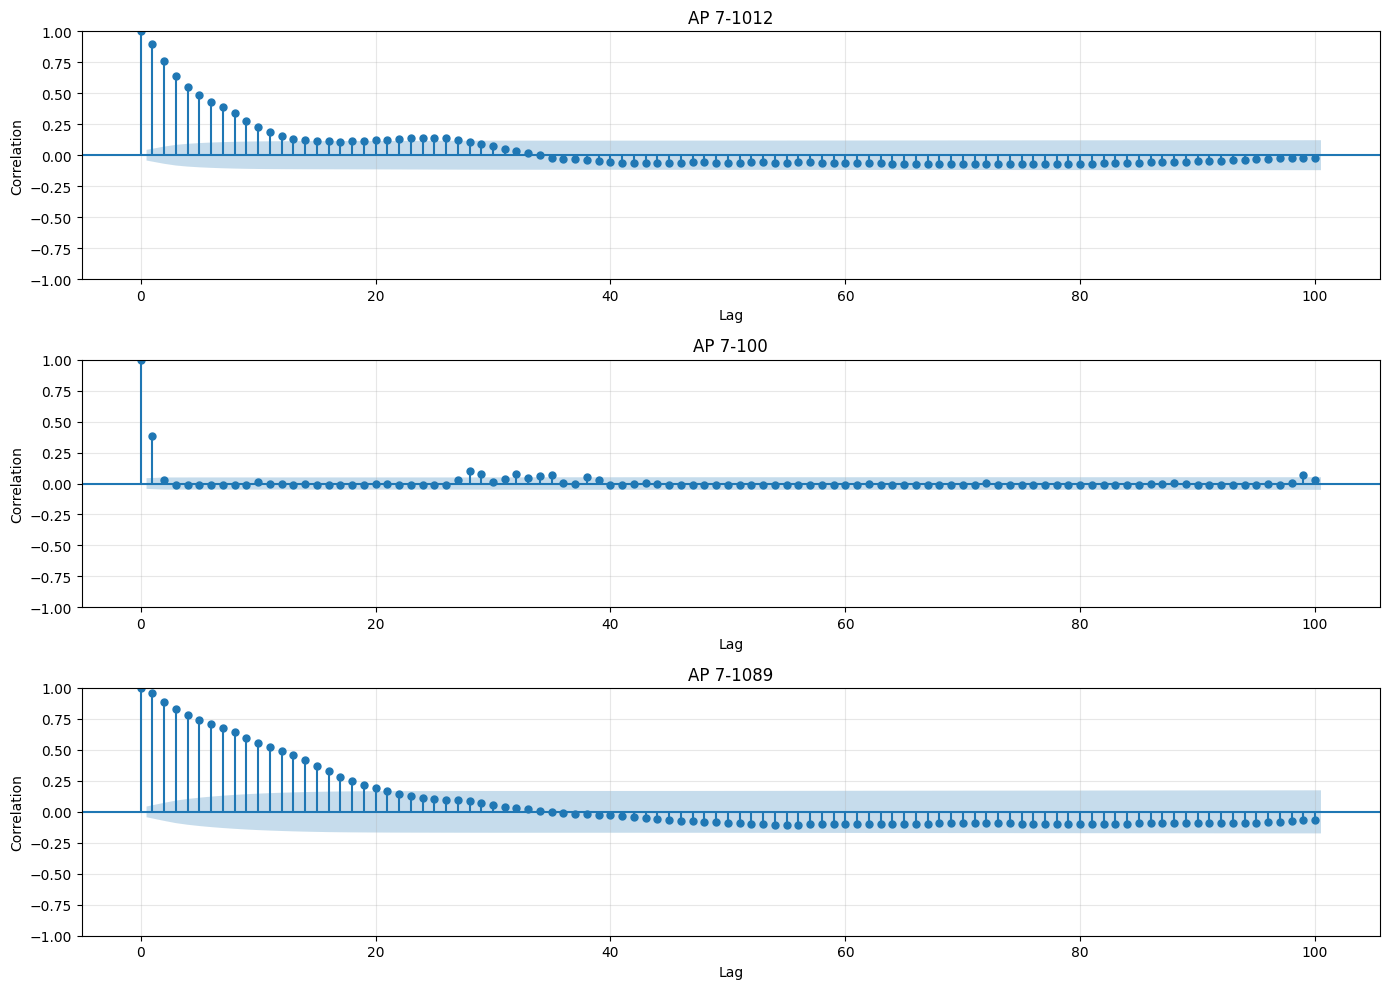

In [10]:
# Autocorrelation plots mira la relacio entre valors passats amb el valor actual, l'ACF t'ho mostra.
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, ap, ap_id in zip(axes, [ap1, ap2, ap3], [ap1_id, ap2_id, ap3_id]):
    plot_acf(ap.dropna(), lags=100, ax=ax, title=f'AP {ap_id}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Et diu si la serie és estacionaria o no. Si ho és la mitjana i la variància no canvien, si no ho és te tendències o canvis de nivells. Si p<0.05: estacionaria; p>0.05: NO estacionaria.
def adf_test(series, ap_id):
    result = adfuller(series.dropna())
    print(f"\n── AP {ap_id} ──")
    print(f"  p-value       : {result[1]:.4f}")
    if result[1] < 0.05:
        print(f"  → ESTACIONARY (p < 0.05)")
    else:
        print(f"  → NO ESTACIONARI (p > 0.05)")

adf_test(ap1, ap1_id)
adf_test(ap2, ap2_id)
adf_test(ap3, ap3_id)


── AP 7-1012 ──
  p-value       : 0.0000
  → ESTACIONARY (p < 0.05)

── AP 7-100 ──
  p-value       : 0.0000
  → ESTACIONARY (p < 0.05)

── AP 7-1089 ──
  p-value       : 0.0000
  → ESTACIONARY (p < 0.05)


After analyzing the data we can see that:

- AP 7-1012: The behavior is irregular and sporadic. The ADF test confirms stationarity (p-value < 0.05), meaning the mean and variance remain stable over time. No growth or decline trend is observed in the number of connected users. The ACF shows a progressive decay, indicating short memory, meaning recent values have a slight influence on future ones.

- AP 7-100: This AP shows almost no user connections, with sporadic and irregular activity that never exceeds 1 active user. It has even shorter memory than AP 7-1012, as the ACF drops to zero almost immediately. The low p-value confirms stationarity, with no temporal structure detectable in the series.

- AP 7-1089: This AP shows more activity than the previous ones, with irregular peaks reaching up to 6-7 users . No clear growth or decline trend is observed either. However, unlike the other two APs, this series shows long memory: the ACF decays slowly, meaning past values have a considerable influence on future ones. The p-value below 0.05 confirms stationarity, so mean and variance remain globally stable.

### Exercise 2:

Prepare the data to be presented as a time series to the ML model. For that, you will have to split features from samples by differentiating between an observation window (e.g., 10 samples) and a prediction window (e.g., 2 samples). Use a sliding window to iterate over all the samples.

Example: For an array [0,1,2,3,4,5], using an observation window $T_o$ = 3 and a prediction window $T_p$ = 1 would lead to the following time series data:
* $x_1$ = [0,1,2], $y_1$ = [3]
* $x_2$ = [1,2,3], $x_2$ = [4]
* $x_3$ = [2,3,4], $y_3$ = [5]

(where x are the features and y the labels)

In [12]:
def sliding_window(series, To, Tp):
    X, Y = [], []
    for i in range(len(series) - To - Tp + 1): # Move the window to the right
        x = series[i : i + To] # Take the values from the actual window
        y = series[i + To : i + To + Tp] # As label
        X.append(x)
        Y.append(y)
    return np.array(X), np.array(Y)

In [13]:
#The model observes the To posterior values and tries to predic the Tp nexts.
To = 3  # observation window
Tp = 1   # prediction window

# Apply to each AP
for ap_id, ap in [('7-1012', ap1), ('7-100', ap2), ('7-1089', ap3)]:
  series = ap.values
  X, Y = sliding_window(series, To, Tp)
  print(f"AP {ap_id}: {X.shape},  {Y.shape}")

AP 7-1012: (2068, 3),  (2068, 1)
AP 7-100: (2065, 3),  (2065, 1)
AP 7-1089: (2050, 3),  (2050, 1)


From the plot we can see that the results for preparing the data are correct, since each sample takes 3 previous values as input (observation window) and predicts 1 future values as output (prediction window), for all samples per AP.


### Exercise 3:

Split the time series data into train, test, and validation, based on your criteria.

In [14]:
train_end = '2019-05-09'
val_end = '2019-05-11'

# Apply to each AP
for ap_id, ap in [('7-1012', ap1), ('7-100', ap2), ('7-1089', ap3)]:
    series = ap.copy()

    train = series[series.index <= train_end]
    val = series[(series.index > train_end) & (series.index <= val_end)]
    test = series[series.index > val_end]

    print(f"AP {ap_id}:")
    print(f"  Train:      {len(train)}")
    print(f"  Validation: {len(val)}")
    print(f"  Test:       {len(test)}")
    print()

AP 7-1012:
  Train:      1254
  Validation: 288
  Test:       529

AP 7-100:
  Train:      1261
  Validation: 288
  Test:       519

AP 7-1089:
  Train:      1251
  Validation: 288
  Test:       514



To split the data, we observed the user activity plots over time and chose specific dates to delimit the three subsets. We decided to split at 2019-05-09, so all data before this date will be used for training. Data between 2019-05-09 and 2019-05-11 will be used for validation, and data after 2019-05-11 will be used for testing. Although the split was done visually, the data ends up reasonably well distributed across the three sets. The training set is slightly larger in proportion, but we consider this appropriate since the model needs enough data to learn from.

### Exercise 4:
Define a model (e.g., GRU, LSTM, CNN, Transformer) able to receive the time series the data you generated in the previous exercise.

In [16]:
# We choose LSTM and we use a libary predefined
# https://www.tensorflow.org/api_docs/python/tf/keras/Sequential
# https://www.tensorflow.org/guide/keras/sequential_model?hl=es-419

To = 3
Tp = 1

# We have 64 neurons in the internal layers of the LSTM. Return false in order to just return the last timestep of the sequence.
model = Sequential([LSTM(64, input_shape=(To, 1), return_sequences=False),Dense(Tp)])
model.compile(optimizer='adam', loss='mse') #The algorithm used to adjust the model. And to calculate the error uses the mean squared error.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### Exercise 5: FALTA AQUEST EXERCICIIIII!!!!

Train your model following two approaches:
1. **Centralized model training:** Mix data from multiple APs to train the model in a centralized fashion.
2. **Federated model training:** Consider APs as independent clients who contribute to training a global model by submitting local model updates.

Show the results by calculating the following metrics from the de-normalized data:
* Mean squared error (MSE)
* Mean absolute error (MAE)
* Mean absolute percentage error (MAPE)

In [17]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [22]:
def evaluate(model, X_test, Y_test, scaler):
    Y_pred = model.predict(X_test)
    # Flatten and reshape to 2D for inverse_transform
    Y_pred = Y_pred.flatten().reshape(-1, 1)
    Y_test = Y_test.flatten().reshape(-1, 1)
    # De-normalize
    Y_pred_denorm = scaler.inverse_transform(Y_pred)
    Y_test_denorm = scaler.inverse_transform(Y_test)
    mse      = mean_squared_error(Y_test_denorm, Y_pred_denorm)
    mae      = mean_absolute_error(Y_test_denorm, Y_pred_denorm)
    mape_val = mape(Y_test_denorm, Y_pred_denorm)
    return mse, mae, mape_val

In [23]:
def build_model(To, Tp):
    model = Sequential([
        LSTM(64, input_shape=(To, 1), return_sequences=False),
        Dense(Tp)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

In [24]:
# PARAMETERS
To     = 3
Tp     = 1
EPOCHS = 30

train_end = '2019-05-09'
val_end   = '2019-05-11'

aps = [('7-1012', ap1), ('7-100', ap2), ('7-1089', ap3)]

ap_data = {}
for ap_id, ap in aps:
    train = ap[ap.index <= train_end].values.reshape(-1, 1)
    val   = ap[(ap.index > train_end) & (ap.index <= val_end)].values.reshape(-1, 1)
    test  = ap[ap.index > val_end].values.reshape(-1, 1)

    # Normalize using train set
    scaler = MinMaxScaler()
    train_norm = scaler.fit_transform(train)
    val_norm   = scaler.transform(val)
    test_norm  = scaler.transform(test)

    # Sliding window
    X_train, Y_train = sliding_window(train_norm, To, Tp)
    X_val,   Y_val   = sliding_window(val_norm,   To, Tp)
    X_test,  Y_test  = sliding_window(test_norm,  To, Tp)

    # Reshape for LSTM: (samples, timesteps, features)
    X_train = X_train.reshape(-1, To, 1)
    X_val   = X_val.reshape(-1, To, 1)
    X_test  = X_test.reshape(-1, To, 1)

    ap_data[ap_id] = {
        'X_train': X_train, 'Y_train': Y_train,
        'X_val':   X_val,   'Y_val':   Y_val,
        'X_test':  X_test,  'Y_test':  Y_test,
        'scaler':  scaler
    }

In [25]:
# CENTRALIZED MODEL TRAINING: All the data from the APs mixed to train a single model.
print("=" * 60)
print("CENTRALIZED TRAINING")
print("=" * 60)

# Mix data from all APs
X_train_central = np.concatenate([ap_data[ap_id]['X_train'] for ap_id, _ in aps])
Y_train_central = np.concatenate([ap_data[ap_id]['Y_train'] for ap_id, _ in aps])
X_val_central   = np.concatenate([ap_data[ap_id]['X_val']   for ap_id, _ in aps])
Y_val_central   = np.concatenate([ap_data[ap_id]['Y_val']   for ap_id, _ in aps])

central_model = build_model(To, Tp)
central_model.fit(
    X_train_central, Y_train_central,
    validation_data=(X_val_central, Y_val_central),
    epochs=EPOCHS, batch_size=32, verbose=1
)

# Evaluate per AP
print("\nCentralized results per AP:")
for ap_id, _ in aps:
    mse, mae, mape_val = evaluate(
        central_model,
        ap_data[ap_id]['X_test'],
        ap_data[ap_id]['Y_test'],
        ap_data[ap_id]['scaler']
    )
    print(f"  AP {ap_id} → MSE: {mse:.4f} | MAE: {mae:.4f} | MAPE: {mape_val:.2f}%")

CENTRALIZED TRAINING
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0071 - val_loss: 0.0037
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0045 - val_loss: 0.0028
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0041 - val_loss: 0.0028
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037 - val_loss: 0.0023
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0018
Epoch 8/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0022
Epoch 9/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0020
Epoch 10/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0021
Epoch 11/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0020
Epoch 12/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

In [26]:
# FEDERATED MODEL TRAINING: Each AP train a different model
print("\n" + "=" * 60)
print("FEDERATED TRAINING (FedAvg)")
print("=" * 60)

NUM_ROUNDS = 10

# Initialize global model
global_model = build_model(To, Tp)

for round_num in range(1, NUM_ROUNDS + 1):
    local_weights = []

    # Each AP trains locally
    for ap_id, _ in aps:
        local_model = build_model(To, Tp)
        local_model.set_weights(global_model.get_weights())  # start from global weights
        local_model.fit(
            ap_data[ap_id]['X_train'], ap_data[ap_id]['Y_train'],
            validation_data=(ap_data[ap_id]['X_val'], ap_data[ap_id]['Y_val']),
            epochs=EPOCHS, batch_size=32, verbose=0
        )
        local_weights.append(local_model.get_weights())

    # FedAvg: average the weights of all local models
    avg_weights = [
        np.mean([local_weights[i][layer] for i in range(len(aps))], axis=0)
        for layer in range(len(local_weights[0]))
    ]
    global_model.set_weights(avg_weights)
    print(f"Round {round_num}/{NUM_ROUNDS} completed")

# Evaluate per AP
print("\nFederated results per AP:")
for ap_id, _ in aps:
    mse, mae, mape_val = evaluate(
        global_model,
        ap_data[ap_id]['X_test'],
        ap_data[ap_id]['Y_test'],
        ap_data[ap_id]['scaler']
    )
    print(f"  AP {ap_id} → MSE: {mse:.4f} | MAE: {mae:.4f} | MAPE: {mape_val:.2f}%")


FEDERATED TRAINING (FedAvg)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Round 1/10 completed
Round 2/10 completed
Round 3/10 completed
Round 4/10 completed
Round 5/10 completed
Round 6/10 completed
Round 7/10 completed
Round 8/10 completed
Round 9/10 completed
Round 10/10 completed

Federated results per AP:
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
  AP 7-1012 → MSE: 0.0778 | MAE: 0.1537 | MAPE: 68.23%
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
  AP 7-100 → MSE: 0.0073 | MAE: 0.0249 | MAPE: 149.48%
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
  AP 7-1089 → MSE: 0.0745 | MAE: 0.1269 | MAPE: 106.73%


For the CENTRALIZED MODEL TRAINING, we see for example for the first AP that the errors are: MSE = 0.0722, MAE = 0.0055 and MAPE = 0.0650. For the FEDERATED MODEL TRAINING, the errors are: MSE = 0.0778, MAE = 0.0073 and MAPE = 0.0745. The centralized approach achieves slightly lower errors across all metrics, which means the model trained on pooled data generalizes better on this dataset. However, the difference is small, suggesting that federated learning is also a good alternative.

### Exercise 6 (EXTRA):

Reconsider your design to improve the accuracy of your model. For that, you can find a better approach to split the data (e.g., using larger observation windows) and include additional features.

In [ ]:
# (response to exercise 6)
